# Action-Delay (Action-Gap) Method Comparison

This notebook summarizes the action-delay sim2real experiments, mirroring
`analyze_transitions.ipynb`. It reads the tab-separated `*_DTL.log` files written
under `data/output_data/sim2real_actions/{world}_{agent}/{network}/{method}_{setting}/logger/`
and compares the mitigation methods:

- **`naive`** — direct transfer: trained in delay-free sim, deployed into the delayed real env, no compensation. **Used as the baseline** for the gap calculation.
- **`oblivious_q`** — trained *under* the delay but ignores it (no prediction).
- **`delayed_q`** — Delayed-Q: predicts the state `m` steps ahead by rolling a one-step model over the in-flight action queue, then acts on the prediction.
- **`prlight`** — PRLight: one-shot neighbor-aware predictor of the state `m` steps ahead.

**Settings = real execution delay** (sim-steps): `setting1`=20, `setting2`=30,
`setting3`=40, `setting4`=60. The method configs freeze the *assumed* delay at
`sim_action_delay=20`, so settings 2–4 measure the **sim↔real delay mismatch**
(rigidity) of a model shipped for a 20-step countdown.

**Metric rule:** for each method/network/setting we take the top `TOP_REWARD_K`
`TEST_REAL` rows by reward from the newest DTL log and average their metrics
(same top-reward selection used in the transitions notebook). Travel time is the
headline metric; lower is better.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

OUTPUT_ROOT = Path("data/output_data/sim2real_actions")
AGENT = "dqn"
WORLD = "cityflow"
TOP_REWARD_K = 5

NETWORK_ORDER = ["tempe_1x1", "cologne3"]
SETTING_ORDER = ["setting1", "setting2", "setting3", "setting4"]
SETTING_DELAY = {"setting1": 20, "setting2": 30, "setting3": 40, "setting4": 60}
METHOD_ORDER = ["naive", "oblivious_q", "delayed_q", "prlight"]
BASELINE_METHOD = "naive"  # direct transfer is the gap reference

# DTL columns are written by Sim2RealActionsTrainer.writeLog (tab-separated):
# exp_name, mode, episode/step, travel_time, loss, reward, queue, delay, throughput
COLUMNS = ["exp_name", "mode", "episode", "travel_time", "loss",
           "reward", "queue", "delay", "throughput"]
METRIC_COLUMNS = ["travel_time", "reward", "queue", "delay", "throughput"]
NUMERIC_COLUMNS = ["episode", "loss", *METRIC_COLUMNS]

In [2]:
def run_dir(network, method, setting):
    return OUTPUT_ROOT / f"{WORLD}_{AGENT}" / network / f"{method}_{setting}"


def latest_dtl(network, method, setting):
    logger_dir = run_dir(network, method, setting) / "logger"
    if not logger_dir.exists():
        return None
    logs = sorted(logger_dir.glob("*_DTL.log"))
    return logs[-1] if logs else None


def read_tabular_dtl(log_path):
    df = pd.read_csv(log_path, sep="\t", header=None, names=COLUMNS)
    for col in NUMERIC_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def real_eval_rows(network, method, setting):
    # All valid TEST_REAL rows for a run (the real-delay zero-shot eval).
    log_path = latest_dtl(network, method, setting)
    if log_path is None:
        return pd.DataFrame(), None
    df = read_tabular_dtl(log_path)
    rows = df[df["mode"] == "TEST_REAL"].copy()
    rows = rows[rows["travel_time"].notna() & rows["reward"].notna()]
    return rows, log_path


def selected_summary(network, method, setting, top_k=TOP_REWARD_K):
    # Average the top-k TEST_REAL rows by reward.
    rows, log_path = real_eval_rows(network, method, setting)
    if rows.empty:
        return None
    picked = rows.sort_values("reward", ascending=False).head(top_k)
    result = {
        "network": network, "setting": setting, "method": method,
        "action_delay": SETTING_DELAY[setting], "selection_count": len(picked),
        "log_file": log_path.name,
        "selected_episodes": ",".join(str(int(e)) for e in picked["episode"]),
    }
    for col in METRIC_COLUMNS:
        result[col] = float(picked[col].mean())
        result[f"{col}_std"] = float(picked[col].std(ddof=0))
    return result

In [3]:
records = []
for network in NETWORK_ORDER:
    for setting in SETTING_ORDER:
        for method in METHOD_ORDER:
            r = selected_summary(network, method, setting)
            if r is None:
                print(f"missing: {network} / {method} / {setting}")
                continue
            records.append(r)

summary_df = pd.DataFrame(records)
print(f"{len(summary_df)} runs loaded "
      f"({summary_df['network'].nunique()} networks x "
      f"{summary_df['method'].nunique()} methods x "
      f"{summary_df['setting'].nunique()} settings)")
summary_df.head()

32 runs loaded (2 networks x 4 methods x 4 settings)


,network,setting,method,action_delay,selection_count,log_file,selected_episodes,travel_time,travel_time_std,reward,reward_std,queue,queue_std,delay,delay_std,throughput,throughput_std
0,tempe_1x1,setting1,naive,20,5,2026_06_12-10_16_48_DTL.log,"195,165,174,33,156",500.60,39.182241,-135.300,13.034611,205.780,21.395151,0.706,0.013565,1380.4,30.137020
1,tempe_1x1,setting1,oblivious_q,20,5,2026_06_12-13_46_38_DTL.log,"60,42,9,246,36",407.26,32.443588,-96.990,11.303691,150.524,17.865095,0.692,0.014697,1629.4,63.559736
2,tempe_1x1,setting1,delayed_q,20,5,2026_06_12-17_52_28_DTL.log,"21,12,27,25,6",180.38,2.357456,-16.566,0.988506,26.042,1.497229,0.498,0.007483,1833.6,9.971961
3,tempe_1x1,setting1,prlight,20,5,2026_06_12-18_31_47_DTL.log,"216,165,192,147,189",165.12,1.374627,-11.356,0.500024,17.472,0.894995,0.468,0.004000,1849.4,9.478396
4,tempe_1x1,setting2,naive,30,5,2026_06_12-10_36_34_DTL.log,"270,75,78,39,45",629.54,14.564834,-174.194,6.001332,279.388,12.857822,0.720,0.008944,1283.0,199.040699


## Travel-Time Summary

Mean travel time of the selected top-reward `TEST_REAL` rows. Lower is better.

In [4]:
travel_time_table = (
    summary_df.pivot_table(index=["network", "setting"], columns="method",
                           values="travel_time")
    .reindex(columns=METHOD_ORDER)
    .reindex(NETWORK_ORDER, level=0)
)
travel_time_table.round(1)

method              naive  oblivious_q  delayed_q  prlight
network   setting                                         
tempe_1x1 setting1  500.6        407.3      180.4    165.1
          setting2  629.5        454.3      190.4    177.1
          setting3  519.4        578.2      207.2    200.7
          setting4  535.7        602.8      268.0    234.4
cologne3  setting1  299.4        275.1       76.7     76.2
          setting2  294.7        523.8       71.0     65.8
          setting3  441.6        310.1       85.3     82.8
          setting4  561.4        496.4       97.1    101.0

## Availability

Which (network, setting, method) runs were found.

In [5]:
availability = (
    summary_df.assign(found=True)
    .pivot_table(index=["network", "setting"], columns="method", values="found",
                 aggfunc="any", fill_value=False)
    .reindex(columns=METHOD_ORDER)
)
availability

method              naive  oblivious_q  delayed_q  prlight
network   setting                                         
cologne3  setting1   True         True       True     True
          setting2   True         True       True     True
          setting3   True         True       True     True
          setting4   True         True       True     True
tempe_1x1 setting1   True         True       True     True
          setting2   True         True       True     True
          setting3   True         True       True     True
          setting4   True         True       True     True

## Sim2Real Gap (vs. Delay-Free Sim Baseline)

The reference is **naive's first `SIM_TRAIN` episode** travel time — the policy in
its delay-free sim environment (naive trains with `sim_action_delay=0`). Averaged
over the naive runs to smooth episode-0 exploration noise, giving one sim baseline
per network (shared by all methods).

`gap_vs_sim = method_real_travel_time - sim_baseline` for each network/setting.
Positive = how far the real-delay (`TEST_REAL`) travel time sits **above** the
delay-free sim ideal — the sim2real gap. Lower = smaller gap = better mitigation.
All methods (including naive) have a gap, since the baseline is the sim floor.

In [6]:
def naive_sim_baseline(network):
    # naive trains in delay-free sim, so its first SIM_TRAIN episode is the
    # no-delay reference. Average over the naive runs (one per setting) to smooth
    # episode-0 exploration noise -> one sim baseline per network.
    vals = []
    for setting in SETTING_ORDER:
        log_path = latest_dtl(network, BASELINE_METHOD, setting)
        if log_path is None:
            continue
        df = read_tabular_dtl(log_path)
        ep0 = df[(df["mode"] == "SIM_TRAIN") & (df["episode"] == 0)]
        if not ep0.empty:
            vals.append(float(ep0.iloc[0]["travel_time"]))
    return float(np.mean(vals)) if vals else np.nan


sim_baseline = {net: naive_sim_baseline(net) for net in NETWORK_ORDER}
print("sim baseline (naive SIM_TRAIN ep0, delay-free):",
      {k: round(v, 1) for k, v in sim_baseline.items()})

gap_records = []
for _, row in summary_df.iterrows():
    base_tt = sim_baseline.get(row["network"], np.nan)
    gap_records.append({
        "network": row["network"], "setting": row["setting"],
        "action_delay": row["action_delay"], "method": row["method"],
        "travel_time": row["travel_time"], "travel_time_std": row["travel_time_std"],
        "sim_baseline": base_tt,
        "gap_vs_sim": row["travel_time"] - base_tt,
    })
gap_df = pd.DataFrame(gap_records)

gap_table = (
    gap_df.pivot_table(index=["network", "setting"], columns="method",
                       values="gap_vs_sim")
    .reindex(columns=METHOD_ORDER)
    .reindex(NETWORK_ORDER, level=0)
)
gap_table.round(1)

sim baseline (naive SIM_TRAIN ep0, delay-free): {'tempe_1x1': 149.6, 'cologne3': 65.0}


method              naive  oblivious_q  delayed_q  prlight
network   setting                                         
tempe_1x1 setting1  351.0        257.7       30.8     15.5
          setting2  479.9        304.7       40.8     27.5
          setting3  369.8        428.6       57.6     51.1
          setting4  386.1        453.2      118.4     84.8
cologne3  setting1  234.4        210.1       11.7     11.1
          setting2  229.7        458.8        5.9      0.7
          setting3  376.6        245.1       20.2     17.8
          setting4  496.4        431.4       32.1     36.0

## Sim2Real Gap Bar Chart

One chart per network: each method's sim2real gap (real-delay travel time minus
the delay-free sim baseline) across the delay settings. Error bars show the
selected rows' travel-time std. Lower bars = smaller gap = better; all methods are
shown, including naive (its own untreated sim2real gap).

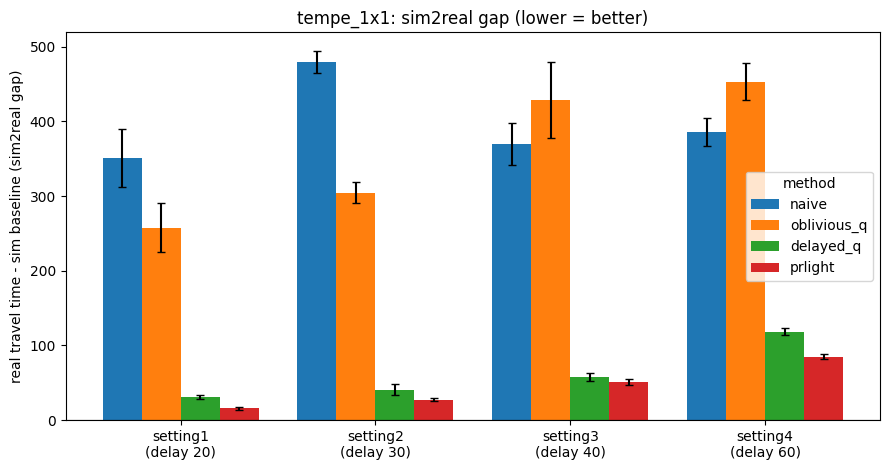

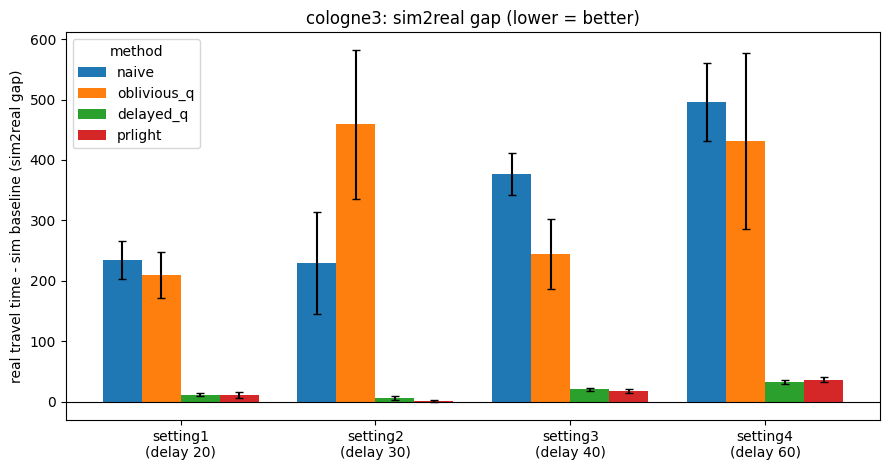

In [7]:
import matplotlib.pyplot as plt

PLOT_METHODS = METHOD_ORDER  # include naive: it has its own (untreated) sim2real gap

for network in NETWORK_ORDER:
    net_df = gap_df[gap_df["network"] == network]
    if net_df.empty:
        continue
    pivot = net_df.pivot_table(index="setting", columns="method",
                               values="gap_vs_sim").reindex(SETTING_ORDER)
    err = net_df.pivot_table(index="setting", columns="method",
                             values="travel_time_std").reindex(SETTING_ORDER)
    methods = [m for m in PLOT_METHODS if m in pivot.columns and pivot[m].notna().any()]
    if not methods:
        continue

    x = np.arange(len(SETTING_ORDER))
    width = 0.8 / len(methods)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for i, method in enumerate(methods):
        offs = x - 0.4 + width / 2 + i * width
        vals = pd.to_numeric(pivot[method], errors="coerce").to_numpy(float)
        errs = pd.to_numeric(err[method], errors="coerce").to_numpy(float)
        mask = ~np.isnan(vals)
        ax.bar(offs[mask], vals[mask], width=width,
               yerr=np.nan_to_num(errs[mask]), capsize=3, label=method)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s}\n(delay {SETTING_DELAY[s]})" for s in SETTING_ORDER])
    ax.set_ylabel("real travel time - sim baseline (sim2real gap)")
    ax.set_title(f"{network}: sim2real gap (lower = better)")
    ax.legend(title="method")
    plt.tight_layout()
    plt.show()

## Picked Metric Mean ± Std

Per network/setting/method, the mean ± std (over the top-reward rows) of each
metric. Saved to `action_table.csv`.

In [8]:
def fmt(mean, std):
    if pd.isna(mean):
        return ""
    if pd.isna(std):
        return f"{mean:.1f}"
    return f"{mean:.1f} ± {std:.1f}"

picked_rows = []
for _, row in summary_df.iterrows():
    rec = {"network": row["network"], "setting": row["setting"],
           "action_delay": row["action_delay"], "method": row["method"],
           "selection_count": row["selection_count"]}
    for col in METRIC_COLUMNS:
        rec[col] = fmt(row[col], row[f"{col}_std"])
    rec["selected_episodes"] = row["selected_episodes"]
    picked_rows.append(rec)

picked_df = pd.DataFrame(picked_rows)
picked_df["network"] = pd.Categorical(picked_df["network"], NETWORK_ORDER, ordered=True)
picked_df["method"] = pd.Categorical(picked_df["method"], METHOD_ORDER, ordered=True)
picked_df = picked_df.sort_values(["network", "setting", "method"]).reset_index(drop=True)
picked_df.to_csv("action_table.csv", index=False)
picked_df

,network,setting,action_delay,method,selection_count,travel_time,reward,queue,delay,throughput,selected_episodes
0,tempe_1x1,setting1,20,naive,5,500.6 ± 39.2,-135.3 ± 13.0,205.8 ± 21.4,0.7 ± 0.0,1380.4 ± 30.1,"195,165,174,33,156"
1,tempe_1x1,setting1,20,oblivious_q,5,407.3 ± 32.4,-97.0 ± 11.3,150.5 ± 17.9,0.7 ± 0.0,1629.4 ± 63.6,"60,42,9,246,36"
2,tempe_1x1,setting1,20,delayed_q,5,180.4 ± 2.4,-16.6 ± 1.0,26.0 ± 1.5,0.5 ± 0.0,1833.6 ± 10.0,"21,12,27,25,6"
3,tempe_1x1,setting1,20,prlight,5,165.1 ± 1.4,-11.4 ± 0.5,17.5 ± 0.9,0.5 ± 0.0,1849.4 ± 9.5,"216,165,192,147,189"
4,tempe_1x1,setting2,30,naive,5,629.5 ± 14.6,-174.2 ± 6.0,279.4 ± 12.9,0.7 ± 0.0,1283.0 ± 199.0,"270,75,78,39,45"
5,tempe_1x1,setting2,30,oblivious_q,5,454.3 ± 13.9,-116.6 ± 4.9,180.1 ± 7.4,0.7 ± 0.0,1468.0 ± 39.4,"102,153,33,159,207"
6,tempe_1x1,setting2,30,delayed_q,5,190.4 ± 7.5,-19.9 ± 2.6,31.1 ± 4.1,0.5 ± 0.0,1829.2 ± 11.3,"17,18,24,22,14"
7,tempe_1x1,setting2,30,prlight,5,177.1 ± 2.2,-15.3 ± 0.8,23.7 ± 1.2,0.5 ± 0.0,1853.4 ± 2.7,"234,90,60,54,72"
8,tempe_1x1,setting3,40,naive,5,519.4 ± 28.0,-137.7 ± 8.5,217.8 ± 16.6,0.7 ± 0.0,1357.2 ± 94.9,"126,84,147,246,222"
9,tempe_1x1,setting3,40,oblivious_q,5,578.2 ± 51.4,-159.0 ± 18.8,245.1 ± 26.6,0.7 ± 0.0,1389.0 ± 57.3,"39,243,297,144,246"


## Real-Eval Travel-Time Traces

`TEST_REAL` travel time over training episodes, one subplot per (network, setting),
one line per method. Shows convergence/stability of the zero-shot real-delay
performance (x-axis is the eval episode; methods may differ in eval cadence).

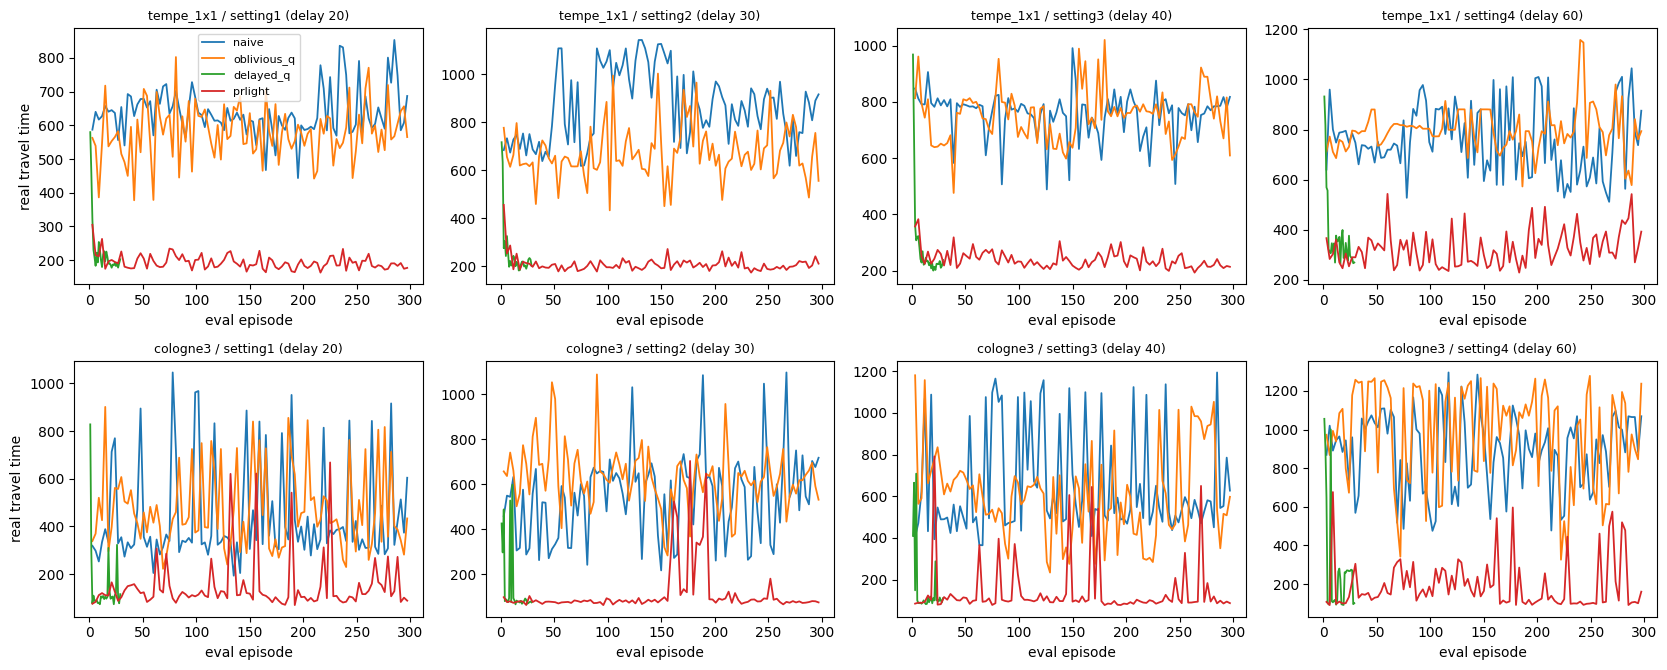

In [9]:
fig, axes = plt.subplots(len(NETWORK_ORDER), len(SETTING_ORDER),
                         figsize=(4.2 * len(SETTING_ORDER), 3.4 * len(NETWORK_ORDER)),
                         squeeze=False)
for r, network in enumerate(NETWORK_ORDER):
    for c, setting in enumerate(SETTING_ORDER):
        ax = axes[r][c]
        for method in METHOD_ORDER:
            rows, _ = real_eval_rows(network, method, setting)
            if rows.empty:
                continue
            rows = rows.sort_values("episode")
            ax.plot(rows["episode"], rows["travel_time"], label=method, linewidth=1.3)
        ax.set_title(f"{network} / {setting} (delay {SETTING_DELAY[setting]})", fontsize=9)
        ax.set_xlabel("eval episode")
        if c == 0:
            ax.set_ylabel("real travel time")
        if r == 0 and c == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.show()